# Week 5 - Support Vector Machines, the Kernel Trick, and Regularization

I classify both binary targets with Support Vector Machines (SVMs):

* Dataset A - Credit card: `is_fraud`
* Dataset B - UNSW-NB15: `label` 

An SVM finds the maximum-margin boundary.The kernel trick lets it bend that
boundary and regularization through the soft-margin `C` and the RBF `gamma` controls how
flexible it is.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
RNG = 42

cc = pd.read_csv("data/credit_card_fraud_dataset.csv")
cc["log_amount"] = np.log1p(cc["transaction_amount_usd"])
cc_continuous = ["credit_utilization_pct", "avg_monthly_spend_usd", "annual_income_usd",
                 "credit_limit_usd", "distance_from_home_km", "num_transactions_last_30d",
                 "age", "credit_score", "account_age_months", "velocity_last_1h"]
cc_binary = ["is_international_transaction", "is_new_merchant", "is_night_transaction",
             "card_present", "cvv_mismatch", "device_changed"]
cc_categorical = ["merchant_category", "device_type", "occupation"]
cc_clf_feats = ["cvv_mismatch", "prev_fraud_flags", "failed_attempts_last_24h", "device_changed",
                "is_international_transaction", "is_new_merchant", "card_present",
                "is_night_transaction", "velocity_last_1h", "credit_utilization_pct",
                "transaction_amount_usd", "distance_from_home_km", "num_transactions_last_30d",
                "age", "credit_score"]

def cc_regression_design():
    X = pd.concat([
        cc[cc_continuous].reset_index(drop=True),
        cc[cc_binary].reset_index(drop=True).astype(float),
        pd.get_dummies(cc[cc_categorical], drop_first=True).reset_index(drop=True).astype(float),
    ], axis=1)
    return X, cc["log_amount"].values

def cc_classification_design():
    return cc[cc_clf_feats].copy(), cc["is_fraud"].values

unsw_full = pd.read_parquet("data_unsw/UNSW_NB15_training-set.parquet")
unsw = unsw_full.groupby("label", group_keys=False).sample(frac=50000/len(unsw_full), random_state=RNG)
unsw = unsw.reset_index(drop=True)
unsw["log_dur"] = np.log1p(unsw["dur"].clip(lower=0))
_top_proto = unsw["proto"].value_counts().head(6).index
unsw["proto_grp"] = np.where(unsw["proto"].isin(_top_proto), unsw["proto"].astype(str), "other")
unsw_cats = ["service", "state", "proto_grp"]
unsw_numeric = [c for c in unsw.select_dtypes(include=[np.number]).columns
                if c not in ("label", "dur", "log_dur")]

def _unsw_dummies():
    return pd.get_dummies(unsw[unsw_cats].astype(str), drop_first=True).reset_index(drop=True).astype(float)

def unsw_regression_design():
    X = pd.concat([unsw[unsw_numeric].reset_index(drop=True), _unsw_dummies()], axis=1)
    return X, unsw["log_dur"].values

def unsw_classification_design():
    num = [c for c in unsw.select_dtypes(include=[np.number]).columns if c not in ("label", "log_dur")]
    X = pd.concat([unsw[num].reset_index(drop=True), _unsw_dummies()], axis=1)
    return X, unsw["label"].values

print("Credit card:", cc.shape, "| fraud rate", round(cc.is_fraud.mean(), 3))
print("UNSW sample:", unsw.shape, "| attack rate", round(unsw.label.mean(), 3))


Credit card: (55000, 30) | fraud rate 0.038
UNSW sample: (50000, 38) | attack rate 0.681


In [8]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import roc_auc_score, f1_score, classification_report

def svm_block(X, y, name, balanced=False, cap=3000):
    df = pd.DataFrame(X); df["_y"] = y
    # Iterate groups directly so the grouping column "_y" is retained
    # (pandas 3.0's groupby.apply drops it by default).
    sub = pd.concat([g.sample(min(len(g), cap), random_state=RNG) for _, g in df.groupby("_y")])
    Xs = sub.drop(columns="_y").values; ys = sub["_y"].values
    Xtr, Xte, ytr, yte = train_test_split(Xs, ys, test_size=0.25, stratify=ys, random_state=RNG)
    sc = StandardScaler().fit(Xtr); Xtr_s, Xte_s = sc.transform(Xtr), sc.transform(Xte)
    print(f"{name} (subsample {Xs.shape})")
    for k in ["linear", "rbf"]:
        m = SVC(kernel=k, C=1.0, gamma="scale", class_weight="balanced").fit(Xtr_s, ytr)
        print(f"  {k:7s} kernel: test ROC-AUC={roc_auc_score(yte, m.decision_function(Xte_s)):.4f}")
    gcv = GridSearchCV(make_pipeline(StandardScaler(), SVC(kernel="rbf", class_weight="balanced")),
                       {"svc__C": [0.1, 1, 10, 100], "svc__gamma": ["scale", 0.01, 0.1, 1]},
                       scoring="roc_auc", cv=3, n_jobs=-1).fit(Xtr, ytr)
    proba = gcv.decision_function(Xte); pred = gcv.predict(Xte)
    print("  Best params:", gcv.best_params_)
    print(f"  Tuned RBF: test ROC-AUC={roc_auc_score(yte, proba):.4f}  F1={f1_score(yte, pred):.4f}")
    return (Xtr, Xte, ytr, yte), gcv

## Dataset A - Credit card: linear vs RBF, and an overfitting demonstration

In [9]:
ccX, ccy = cc_classification_design()
cc_data, cc_gcv = svm_block(ccX, ccy, "Credit card - is_fraud", balanced=True)

Credit card - is_fraud (subsample (5074, 15))
  linear  kernel: test ROC-AUC=1.0000
  rbf     kernel: test ROC-AUC=0.9999


  Best params: {'svc__C': 10, 'svc__gamma': 0.01}
  Tuned RBF: test ROC-AUC=1.0000  F1=0.9971


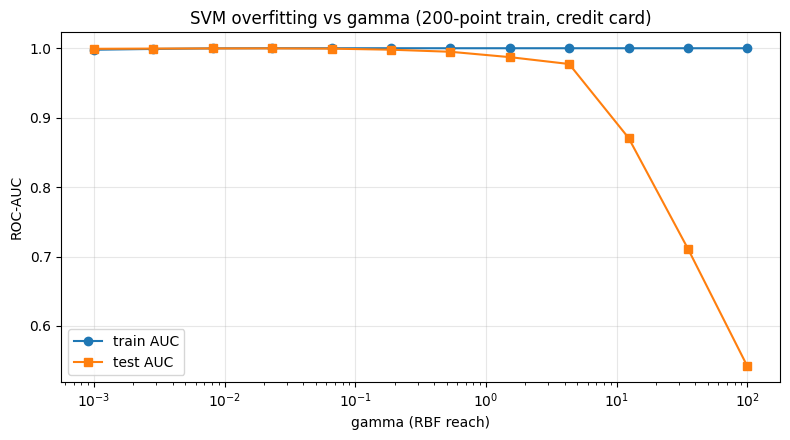

smallest gamma: train=0.998 test=0.999 | largest gamma: train=1.000 test=0.542


In [10]:
Xtr, Xte, ytr, yte = cc_data
Xs, _, ys, _ = train_test_split(Xtr, ytr, train_size=200, stratify=ytr, random_state=0)
sc = StandardScaler().fit(Xs); Xs_s, Xte_s = sc.transform(Xs), sc.transform(Xte)
gammas = np.logspace(-3, 2, 12); tr, te = [], []
for g in gammas:
    s = SVC(kernel="rbf", C=1.0, gamma=g, class_weight="balanced").fit(Xs_s, ys)
    tr.append(roc_auc_score(ys, s.decision_function(Xs_s))); te.append(roc_auc_score(yte, s.decision_function(Xte_s)))
plt.figure(figsize=(8, 4.5))
plt.semilogx(gammas, tr, "o-", label="train AUC"); plt.semilogx(gammas, te, "s-", label="test AUC")
plt.xlabel("gamma (RBF reach)"); plt.ylabel("ROC-AUC"); plt.title("SVM overfitting vs gamma (200-point train, credit card)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f"smallest gamma: train={tr[0]:.3f} test={te[0]:.3f} | largest gamma: train={tr[-1]:.3f} test={te[-1]:.3f}")

As `gamma` grows the training AUC climbs to a perfect 1.0 while the test AUC collapses. The
boundary wraps tightly around each of the 200 training points and stops generalizing. This is
why cross-validation chose a modest `gamma` and it shows concretely how `gamma` and the
soft-margin `C` act as regularizers.

## Dataset B - UNSW: SVM for attack detection

In [11]:
uX, uy = unsw_classification_design()
u_data, u_gcv = svm_block(uX, uy, "UNSW - attack label", balanced=False, cap=3000)

UNSW - attack label (subsample (6000, 55))


  linear  kernel: test ROC-AUC=0.9535
  rbf     kernel: test ROC-AUC=0.9625
  Best params: {'svc__C': 100, 'svc__gamma': 0.01}
  Tuned RBF: test ROC-AUC=0.9691  F1=0.9135


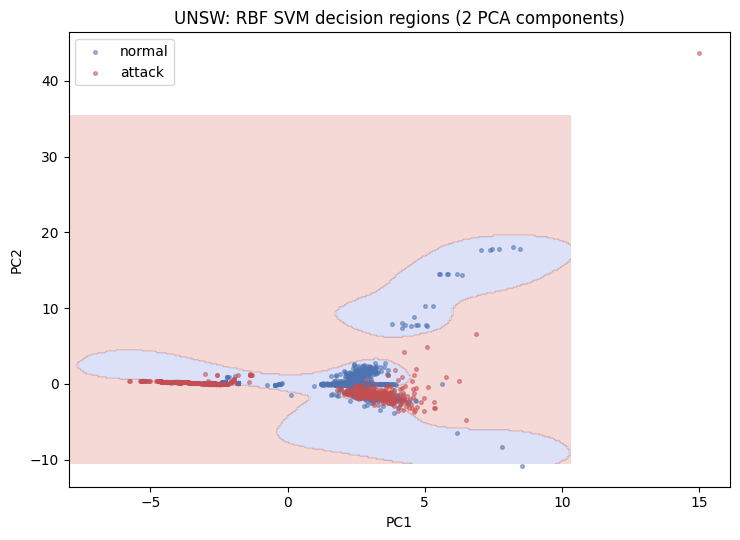

In [12]:
Xtr, Xte, ytr, yte = u_data
sc = StandardScaler().fit(Xtr)
P2 = PCA(2, random_state=RNG).fit(sc.transform(Xtr))
Ztr = P2.transform(sc.transform(Xtr)); Zte = P2.transform(sc.transform(Xte))
svm2d = SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced").fit(Ztr, ytr)
xx, yy = np.meshgrid(np.linspace(Ztr[:,0].min()-1, Ztr[:,0].max()+1, 250),
                     np.linspace(Ztr[:,1].min()-1, Ztr[:,1].max()+1, 250))
Z = svm2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.figure(figsize=(7.5, 5.5))
plt.contourf(xx, yy, Z, alpha=0.2, cmap="coolwarm")
plt.scatter(Zte[yte==0,0], Zte[yte==0,1], s=7, c="#4C72B0", alpha=0.5, label="normal")
plt.scatter(Zte[yte==1,0], Zte[yte==1,1], s=7, c="#C44E52", alpha=0.5, label="attack")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("UNSW: RBF SVM decision regions (2 PCA components)")
plt.legend(); plt.tight_layout(); plt.show()

On UNSW the RBF kernel earns its keep. Attack and normal traffic are not linearly
separable so the curved boundary outperforms or
matches the linear kernel. The tuned model reaches a strong but realistic ROC-AUC well below
the credit-card model's. The kernel trick is genuinely useful here, unlike on the trivially
separable credit-card data.

## Conclusions

* SVMs confirm the two-dataset pattern. Both kernels classify credit-card fraud almost
  perfectly while UNSW yields a strong-but-imperfect detector.
* The kernel trick matters only where the data is nonlinear. It is redundant on the separable
  credit-card data but genuinely improves the UNSW boundary.
* Regularization is the key lesson. It is made vivid by the gamma overfitting curve. Without tuned
  `C` and `gamma`, an SVM will memorize the training set. Cross-validation is what keeps it honest.
